<a href="https://colab.research.google.com/github/Keistkmiya/Introduction-to-Machine-Learning-with-Python/blob/main/Chapter_01_Introduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 1: Introduction
Pada bab ini, kita akan mempelajari konsep dasar Machine Learning melalui studi kasus klasifikasi bunga Iris.

### Library Utama:
- **scikit-learn**: Berisi algoritma machine learning yang akan kita gunakan.
- **NumPy & Pandas**: Untuk pengolahan data angka dan tabel.
- **Matplotlib**: Untuk visualisasi data.

In [1]:
import sys
import pandas as pd
import matplotlib
import numpy as np
import scipy as sp
import IPython
import sklearn

print(f"Versi scikit-learn: {sklearn.__version__}")

Versi scikit-learn: 1.6.1


### 1.1 Meet the Data
Kita akan menggunakan dataset Iris yang berisi data pengukuran mahkota (sepal) dan kelopak (petal) bunga Iris. Tujuan kita adalah mengklasifikasikan spesies bunga berdasarkan ukuran tersebut.

In [2]:
from sklearn.datasets import load_iris
iris_dataset = load_iris()

print("Kunci dalam iris_dataset:", iris_dataset.keys())
print("Target names (Spesies):", iris_dataset['target_names'])
print("Feature names (Fitur):", iris_dataset['feature_names'])

Kunci dalam iris_dataset: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
Target names (Spesies): ['setosa' 'versicolor' 'virginica']
Feature names (Fitur): ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


### 1.2 Training and Testing Data
Dalam Machine Learning, kita tidak boleh menguji model menggunakan data yang sama dengan data saat kita melatihnya. Mengapa? Karena model bisa saja hanya "menghafal" data tersebut (overfitting).

Kita akan membagi data menggunakan fungsi `train_test_split`:
- **Training Data**: 75% dari total data (digunakan untuk melatih model).
- **Testing Data**: 25% dari total data (digunakan untuk mengukur akurasi model).

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    iris_dataset['data'], iris_dataset['target'], random_state=0)

print(f"Bentuk X_train: {X_train.shape}")
print(f"Bentuk y_train: {y_train.shape}")
print(f"Bentuk X_test: {X_test.shape}")
print(f"Bentuk y_test: {y_test.shape}")

Bentuk X_train: (112, 4)
Bentuk y_train: (112,)
Bentuk X_test: (38, 4)
Bentuk y_test: (38,)


### 1.3 Building Your First Model: k-Nearest Neighbors
Kita akan menggunakan algoritma k-NN dengan `n_neighbors=1`. Artinya, model akan memprediksi spesies bunga baru berdasarkan 1 tetangga yang paling mirip di dalam data training.

In [4]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1)

# Melatih model dengan data training
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

### 1.4 Evaluating the Model
Kita akan menggunakan data testing (`X_test`) untuk melihat apakah model bisa menebak dengan benar. Hasilnya disebut sebagai **Accuracy Score**.

In [5]:
y_pred = knn.predict(X_test)
print(f"Hasil Prediksi: \n{y_pred}")

# Menghitung akurasi
print(f"Akurasi model: {knn.score(X_test, y_test):.2f}")

Hasil Prediksi: 
[2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 2]
Akurasi model: 0.97


# Chapter 2: Supervised Learning
Supervised Learning adalah tipe Machine Learning di mana kita memberikan model data beserta jawabannya (label). Tujuannya adalah agar model bisa belajar memetakan input ke output yang benar.

### Dua Tipe Utama:
1. **Classification (Klasifikasi)**: Memprediksi kategori (misal: spam atau bukan spam).
2. **Regression (Regresi)**: Memprediksi angka kontinu (misal: harga rumah atau suhu).

### Konsep Penting:
- **Generalization**: Kemampuan model memprediksi data baru yang belum pernah dilihat.
- **Overfitting**: Model terlalu hafal data latihan sehingga gagal memprediksi data baru.
- **Underfitting**: Model terlalu simpel sehingga tidak paham pola data.

In [7]:
!pip install mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 9.4 MB/s eta 0:00:00


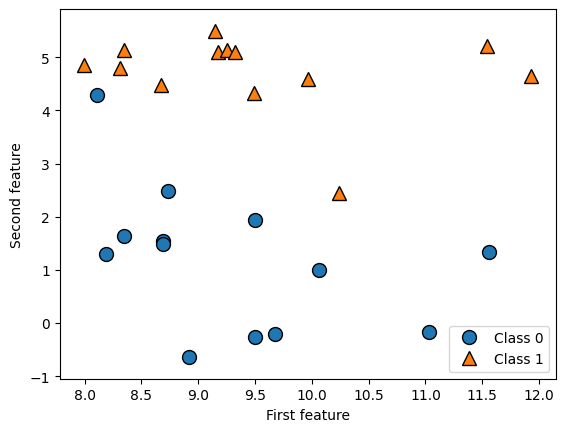

Bentuk data X: (26, 2)


In [8]:
import mglearn
import matplotlib.pyplot as plt
import numpy as np

# Membuat dataset buatan (Forge Dataset untuk Klasifikasi)
X, y = mglearn.tools.make_handcrafted_dataset()

# Visualisasi data
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
plt.legend(["Class 0", "Class 1"], loc=4)
plt.xlabel("First feature")
plt.ylabel("Second feature")
plt.show()

print(f"Bentuk data X: {X.shape}")

### 2.1 k-Nearest Neighbors Regression
Selain untuk klasifikasi, k-NN juga bisa digunakan untuk regresi. Di sini, kita mencoba memprediksi nilai numerik kontinu.

**Cara Kerja:**
- Untuk `n_neighbors=1`, prediksi adalah nilai dari tetangga terdekat.
- Untuk `n_neighbors > 1`, prediksi adalah rata-rata (mean) dari nilai tetangga-tetangga terdekatnya.

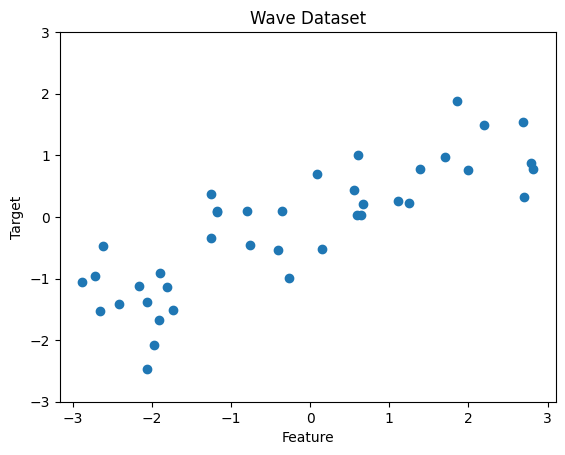

In [9]:
import mglearn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Mengambil dataset wave buatan
X, y = mglearn.datasets.make_wave(n_samples=40)

# Membagi menjadi data training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Visualisasi data awal
plt.plot(X, y, 'o')
plt.ylim(-3, 3)
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Wave Dataset")
plt.show()

In [10]:
from sklearn.neighbors import KNeighborsRegressor

# Membuat instansiasi model
reg = KNeighborsRegressor(n_neighbors=3)

# Melatih model dengan data training
reg.fit(X_train, y_train)

# Melakukan prediksi pada data testing
print(f"Prediksi data testing:\n{reg.predict(X_test)}")

Prediksi data testing:
[-0.05396539  0.35686046  1.13671923 -1.89415682 -1.13881398 -1.63113382
  0.35686046  0.91241374 -0.44680446 -1.13881398]


In [11]:
print(f"Test set R^2: {reg.score(X_test, y_test):.2f}")

Test set R^2: 0.83


### 2.2 Analyzing KNeighborsRegressor
Untuk memahami pengaruh jumlah tetangga terhadap model, kita akan membandingkan prediksi menggunakan 1, 3, dan 9 tetangga.

**Teori Penting:**
- **n_neighbors = 1**: Model sangat mengikuti data training secara detail. Garis prediksi akan terlihat sangat tajam dan tidak beraturan. Ini berisiko menyebabkan **Overfitting**.
- **n_neighbors = banyak (misal 9)**: Prediksi menjadi lebih halus (smooth) karena merupakan rata-rata dari banyak tetangga. Namun, model bisa menjadi terlalu simpel dan kehilangan detail penting, yang disebut **Underfitting**.

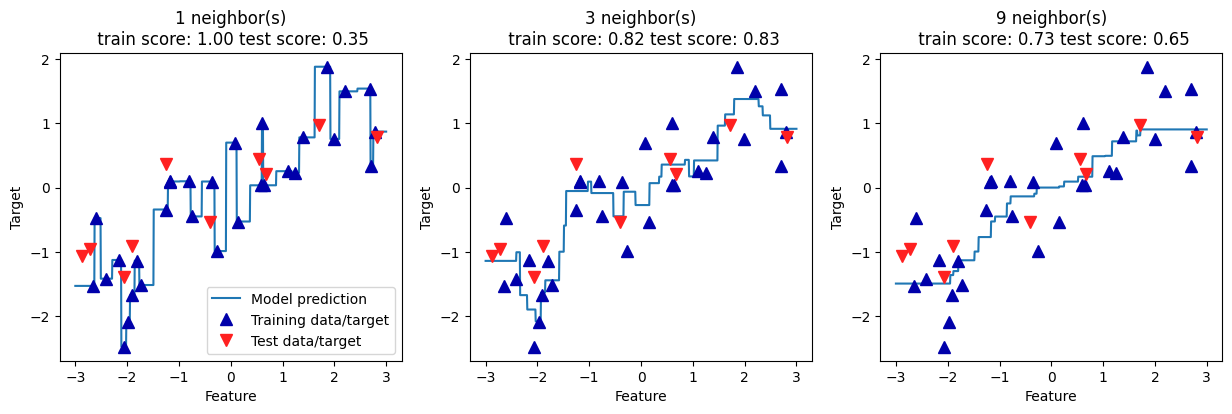

In [12]:
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Membuat 1000 titik data untuk prediksi (garis halus)
line = np.linspace(-3, 3, 1000).reshape(-1, 1)

for n_neighbors, ax in zip([1, 3, 9], axes):
    # Membuat model dan melatihnya
    reg = KNeighborsRegressor(n_neighbors=n_neighbors)
    reg.fit(X_train, y_train)

    # Melakukan prediksi
    ax.plot(line, reg.predict(line))
    ax.plot(X_train, y_train, '^', c=mglearn.cm2(0), markersize=8)
    ax.plot(X_test, y_test, 'v', c=mglearn.cm2(1), markersize=8)

    ax.set_title(
        f"{n_neighbors} neighbor(s)\n train score: {reg.score(X_train, y_train):.2f} "
        f"test score: {reg.score(X_test, y_test):.2f}")
    ax.set_xlabel("Feature")
    ax.set_ylabel("Target")

axes[0].legend(["Model prediction", "Training data/target", "Test data/target"], loc="best")

**Kesimpulan dari Grafik:**
1. Pada **1 neighbor**, skor training sangat sempurna (1.00), tapi garis predisinya sangat bergejolak. Ini adalah tanda model terlalu sensitif terhadap noise pada data.
2. Seiring bertambahnya **neighbors**, garis prediksi menjadi lebih stabil dan halus.
3. Skor terbaik biasanya ditemukan pada titik tengah yang seimbang, di mana model tidak terlalu kompleks tapi juga tidak terlalu sederhana.